# Student Pass/Fail Prediction Using Machine Learning

**Problem Type:** Binary Classification

This project predicts whether a student will **Pass (Yes) or Fail (No)** using academic and behavioral features.

### Five Classification Algorithms
1. Logistic Regression
2. Decision Tree
3. Random Forest
4. K-Nearest Neighbors (KNN)
5. Support Vector Machine (SVM)

### Complete Workflow
Data Analysis → Data Cleaning → EDA → Feature Engineering → Feature Extraction → Feature Compatibility Check → Train/Test Split → Model Training → Model Evaluation → Confusion Matrix → Performance Comparison → Final Model Training → Final Evaluation → Prediction System → Feature Extractor Test → New Feature Creation → Model Test


In [3]:
# 1. IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully!")


Libraries imported successfully!


In [4]:
# 2. LOAD DATASET
DATASET_PATH = "student_performance_prediction_50000_records_10_columns.csv"
df = pd.read_csv(DATASET_PATH)

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])


Dataset loaded successfully!
Rows: 50000
Columns: 10


## 3. DATA ANALYSIS

In [5]:
display(df.head())
display(df.tail())

print("Columns:")
print(df.columns.tolist())

print("\nDataset information:")
df.info()

print("\nStatistical summary:")
display(df.describe(include="all"))

print("\nStudent ID check:")
print("Total Student IDs:", df["Student ID"].nunique())
print("Total Records:", len(df))


,Student ID,Study Hours per Week,Attendance Rate,Previous Grades,Participation in Extracurricular Activities,Parent Education Level,Passed,Assignment Completion Rate,Mock Test Score,Daily Self-Study Hours
0,S00001,12.5,NaN,75.0,Yes,Master,Yes,83,68,2.1
1,S00002,9.3,95.3,60.6,No,High School,No,55,51,1.7
2,S00003,13.2,NaN,64.0,No,Associate,No,77,67,2.1
3,S00004,17.6,76.8,62.4,Yes,Bachelor,No,77,64,3.4
4,S00005,8.8,89.3,72.7,No,Master,No,58,55,1.1


,Student ID,Study Hours per Week,Attendance Rate,Previous Grades,Participation in Extracurricular Activities,Parent Education Level,Passed,Assignment Completion Rate,Mock Test Score,Daily Self-Study Hours
49995,49996,28.0,72.0,61.0,No,High School,No,69,64,3.9
49996,49997,7.0,69.0,72.0,No,Associate,Yes,77,74,1.2
49997,49998,7.0,80.0,55.0,Yes,Doctorate,Yes,80,43,0.5
49998,49999,5.0,97.0,54.0,No,Doctorate,Yes,66,59,0.8
49999,50000,6.0,80.0,53.0,No,Bachelor,No,65,45,1.4


Columns:
['Student ID', 'Study Hours per Week', 'Attendance Rate', 'Previous Grades', 'Participation in Extracurricular Activities', 'Parent Education Level', 'Passed', 'Assignment Completion Rate', 'Mock Test Score', 'Daily Self-Study Hours']

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 10 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   Student ID                                   50000 non-null  str    
 1   Study Hours per Week                         48005 non-null  float64
 2   Attendance Rate                              48008 non-null  float64
 3   Previous Grades                              48006 non-null  float64
 4   Participation in Extracurricular Activities  47525 non-null  str    
 5   Parent Education Level                       47463 non-null  str    
 6   Passed                                 

,Student ID,Study Hours per Week,Attendance Rate,Previous Grades,Participation in Extracurricular Activities,Parent Education Level,Passed,Assignment Completion Rate,Mock Test Score,Daily Self-Study Hours
count,50000,48005.000000,48008.000000,48006.000000,47525,47463,47469,50000.000000,50000.000000,50000.000000
unique,50000,NaN,NaN,NaN,2,5,2,NaN,NaN,NaN
top,S00001,NaN,NaN,NaN,No,High School,No,NaN,NaN,NaN
freq,1,NaN,NaN,NaN,23836,9595,23880,NaN,NaN,NaN
mean,NaN,10.600565,74.985825,65.443688,NaN,NaN,NaN,70.149740,65.253860,1.517552
std,NaN,7.906325,19.955432,16.199974,NaN,NaN,NaN,17.135082,16.588383,0.768355
min,NaN,-12.300000,-14.300000,3.000000,NaN,NaN,NaN,0.000000,0.000000,0.500000
25%,NaN,6.500000,61.700000,55.100000,NaN,NaN,NaN,59.000000,54.000000,0.900000
50%,NaN,10.000000,75.000000,65.300000,NaN,NaN,NaN,71.000000,65.000000,1.500000
75%,NaN,13.600000,88.700000,75.100000,NaN,NaN,NaN,83.000000,77.000000,2.000000



Student ID check:
Total Student IDs: 50000
Total Records: 50000


## 4. DATA CLEANING

Missing target values cannot be used for supervised learning, so those rows are removed. Missing numerical inputs are filled with the median, and missing categorical inputs are filled with the mode.


In [6]:
print("Missing values before cleaning:")
display(df.isnull().sum())

print("Duplicate records:", df.duplicated().sum())

df = df.drop_duplicates().copy()
df = df.dropna(subset=["Passed"]).copy()

X = df.drop(["Student ID", "Passed"], axis=1).copy()
y = df["Passed"].copy()

numerical_columns = [
    "Study Hours per Week", "Attendance Rate", "Previous Grades",
    "Assignment Completion Rate", "Mock Test Score", "Daily Self-Study Hours"
]
categorical_columns = [
    "Participation in Extracurricular Activities", "Parent Education Level"
]

for col in numerical_columns:
    X[col] = X[col].fillna(X[col].median())

for col in categorical_columns:
    X[col] = X[col].fillna(X[col].mode()[0])

print("\nMissing values after cleaning:")
display(X.isnull().sum())
print("Usable records:", len(X))


Missing values before cleaning:


Student ID                                        0
Study Hours per Week                           1995
Attendance Rate                                1992
Previous Grades                                1994
Participation in Extracurricular Activities    2475
Parent Education Level                         2537
Passed                                         2531
Assignment Completion Rate                        0
Mock Test Score                                   0
Daily Self-Study Hours                            0
dtype: int64

Duplicate records: 0

Missing values after cleaning:


Study Hours per Week                           0
Attendance Rate                                0
Previous Grades                                0
Participation in Extracurricular Activities    0
Parent Education Level                         0
Assignment Completion Rate                     0
Mock Test Score                                0
Daily Self-Study Hours                         0
dtype: int64

Usable records: 47469


## 5. EXPLORATORY DATA ANALYSIS (EDA)

Pass/Fail distribution:


Passed
No     23880
Yes    23589
Name: count, dtype: int64

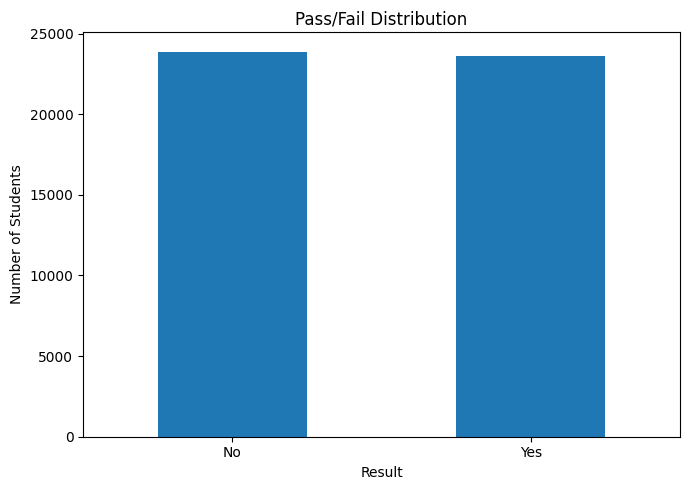

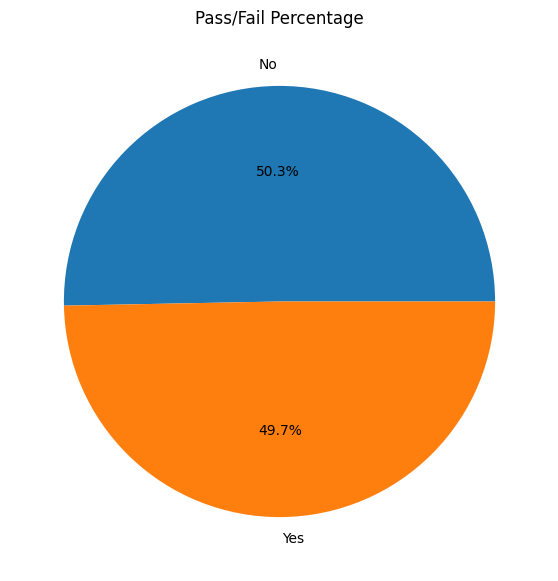

In [7]:
print("Pass/Fail distribution:")
display(df["Passed"].value_counts())

plt.figure(figsize=(7,5))
df["Passed"].value_counts().plot(kind="bar")
plt.title("Pass/Fail Distribution")
plt.xlabel("Result")
plt.ylabel("Number of Students")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7,7))
df["Passed"].value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.title("Pass/Fail Percentage")
plt.ylabel("")
plt.show()


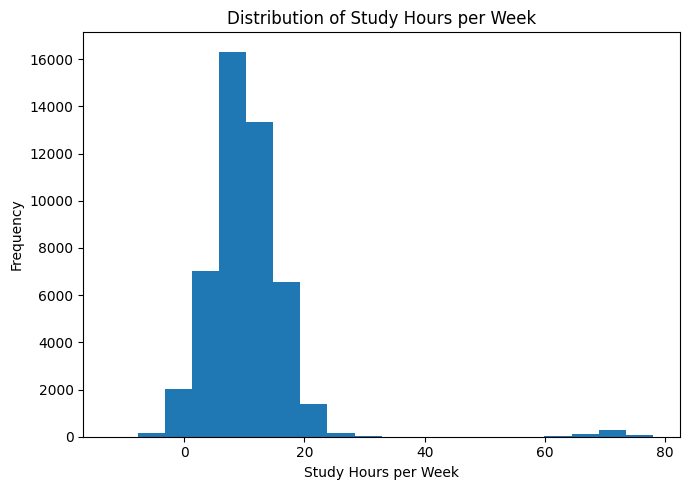

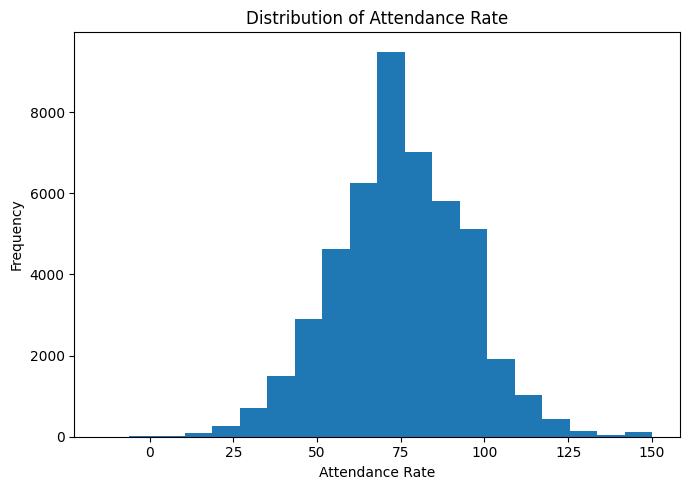

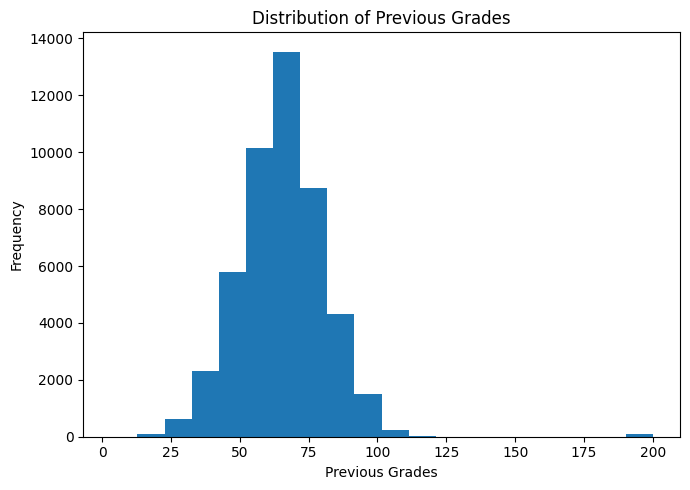

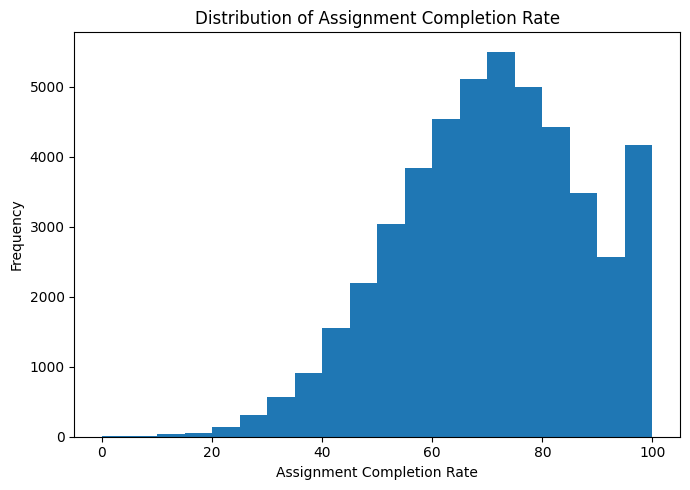

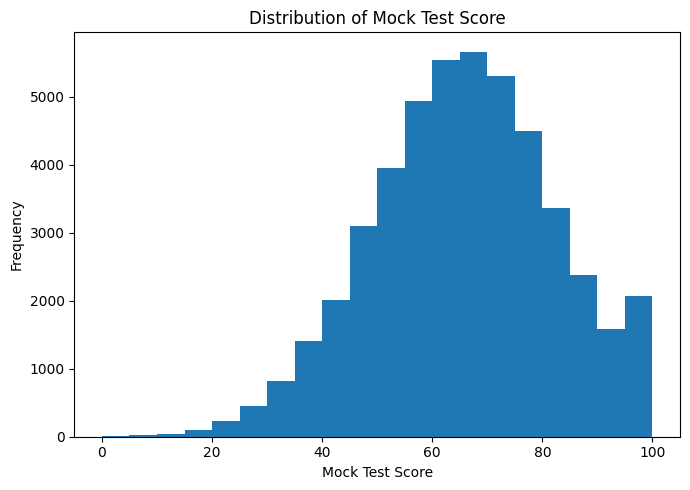

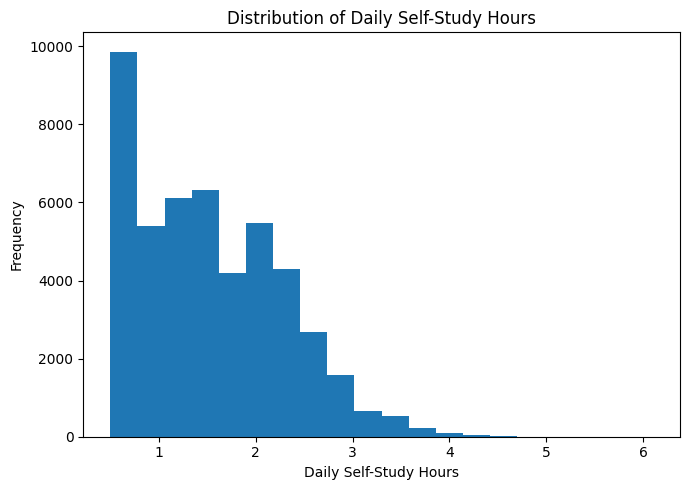

In [8]:
for col in numerical_columns:
    plt.figure(figsize=(7,5))
    plt.hist(X[col], bins=20)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()


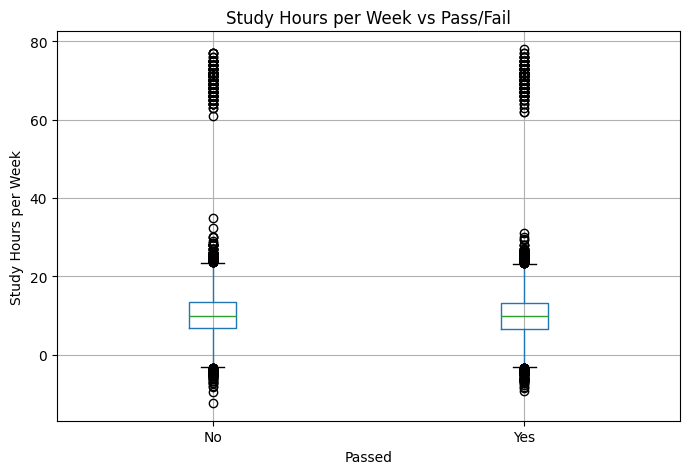

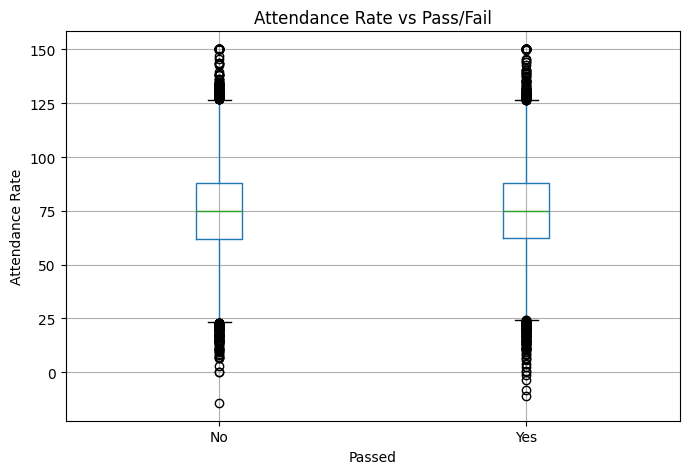

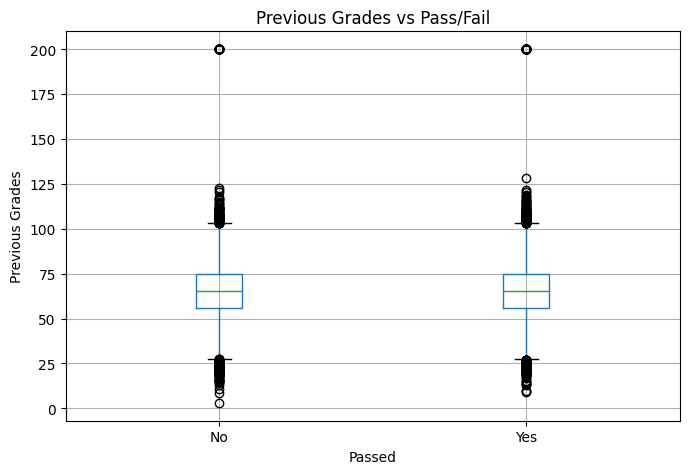

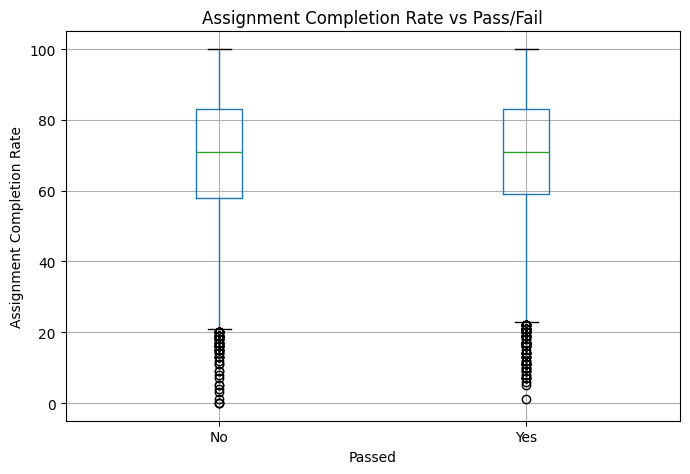

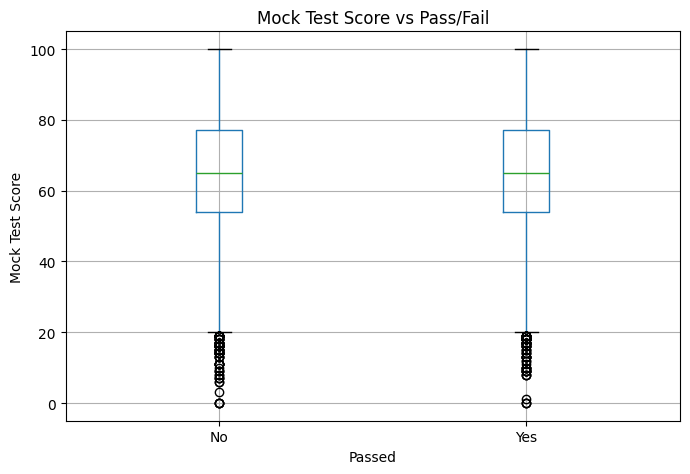

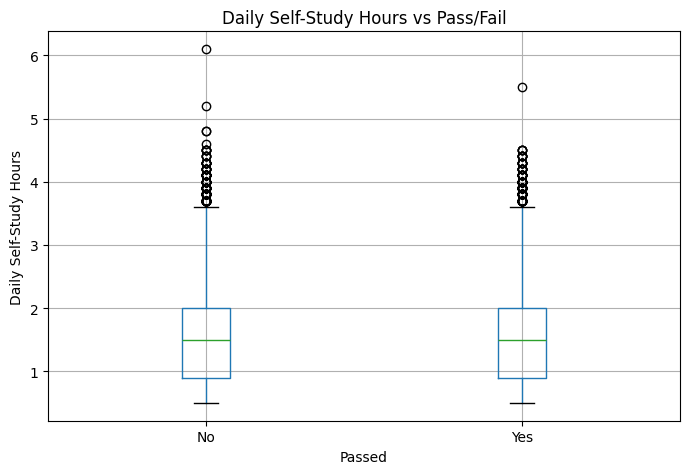

In [9]:
# Boxplots: numerical features vs Pass/Fail
eda_temp = X.copy()
eda_temp["Passed"] = y.values

for col in numerical_columns:
    eda_temp.boxplot(column=col, by="Passed", figsize=(7,5))
    plt.title(f"{col} vs Pass/Fail")
    plt.suptitle("")
    plt.xlabel("Passed")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()


## 6. FEATURE ENGINEERING AND FEATURE EXTRACTION

`Student ID` is removed because it is only an identifier. Categorical input features and the target are encoded separately.


In [10]:
feature_encoders = {}

for col in categorical_columns:
    encoder = LabelEncoder()
    X[col] = encoder.fit_transform(X[col].astype(str))
    feature_encoders[col] = encoder

target_encoder = LabelEncoder()
y = target_encoder.fit_transform(y.astype(str))

print("Target classes:", target_encoder.classes_)
print("Unique encoded target values:", np.unique(y))
print("\nTarget distribution:")
display(pd.Series(y).value_counts().sort_index())

print("\nFeatures used:")
print(X.columns.tolist())


Target classes: ['No' 'Yes']
Unique encoded target values: [0 1]

Target distribution:


0    23880
1    23589
Name: count, dtype: int64


Features used:
['Study Hours per Week', 'Attendance Rate', 'Previous Grades', 'Participation in Extracurricular Activities', 'Parent Education Level', 'Assignment Completion Rate', 'Mock Test Score', 'Daily Self-Study Hours']


## 7. FEATURE COMPATIBILITY CHECK

- Logistic Regression → scaled features
- KNN → scaled features
- SVM → scaled features
- Decision Tree → original encoded features
- Random Forest → original encoded features


In [11]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print("Training data:", X_train.shape)
print("Testing data :", X_test.shape)

# Scaling for Logistic Regression, KNN and SVM
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled training data:", X_train_scaled.shape)
print("Scaled testing data :", X_test_scaled.shape)
print("NaN in scaled training:", np.isnan(X_train_scaled).sum())
print("NaN in scaled testing :", np.isnan(X_test_scaled).sum())


Training data: (37975, 8)
Testing data : (9494, 8)
Scaled training data: (37975, 8)
Scaled testing data : (9494, 8)
NaN in scaled training: 0
NaN in scaled testing : 0


## 8. MODEL TRAINING — FIVE CLASSIFICATION ALGORITHMS

In [12]:
# 1. Logistic Regression
lr_model = LogisticRegression(random_state=42, max_iter=5000)
lr_model.fit(X_train_scaled, y_train)
lr_pred = lr_model.predict(X_test_scaled)

# 2. Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)

# 3. Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

# 4. KNN
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)
knn_pred = knn_model.predict(X_test_scaled)

# 5. SVM
svm_model = SVC(kernel="rbf", random_state=42)
svm_model.fit(X_train_scaled, y_train)
svm_pred = svm_model.predict(X_test_scaled)

print("All five models trained successfully!")


All five models trained successfully!


## 9. MODEL EVALUATION

In [13]:
predictions = {
    "Logistic Regression": lr_pred,
    "Decision Tree": dt_pred,
    "Random Forest": rf_pred,
    "KNN": knn_pred,
    "SVM": svm_pred
}

results_list = []

for name, pred in predictions.items():
    acc = accuracy_score(y_test, pred)
    prec = precision_score(y_test, pred, zero_division=0)
    rec = recall_score(y_test, pred, zero_division=0)
    f1 = f1_score(y_test, pred, zero_division=0)

    results_list.append([name, acc, prec, rec, f1])

    print("=" * 65)
    print(name)
    print("=" * 65)
    print("Accuracy :", round(acc*100, 2), "%")
    print("Precision:", round(prec*100, 2), "%")
    print("Recall   :", round(rec*100, 2), "%")
    print("F1 Score :", round(f1*100, 2), "%")
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, pred))
    print("\nClassification Report:")
    print(classification_report(
        y_test, pred,
        target_names=target_encoder.classes_,
        zero_division=0
    ))


Logistic Regression
Accuracy : 50.88 %
Precision: 50.9 %
Recall   : 33.06 %
F1 Score : 40.09 %

Confusion Matrix:
[[3271 1505]
 [3158 1560]]

Classification Report:
              precision    recall  f1-score   support

          No       0.51      0.68      0.58      4776
         Yes       0.51      0.33      0.40      4718

    accuracy                           0.51      9494
   macro avg       0.51      0.51      0.49      9494
weighted avg       0.51      0.51      0.49      9494

Decision Tree
Accuracy : 52.04 %
Precision: 51.75 %
Recall   : 51.61 %
F1 Score : 51.68 %

Confusion Matrix:
[[2506 2270]
 [2283 2435]]

Classification Report:
              precision    recall  f1-score   support

          No       0.52      0.52      0.52      4776
         Yes       0.52      0.52      0.52      4718

    accuracy                           0.52      9494
   macro avg       0.52      0.52      0.52      9494
weighted avg       0.52      0.52      0.52      9494

Random Forest
Accurac

## 10. PERFORMANCE COMPARISON

In [14]:
results = pd.DataFrame(
    results_list,
    columns=["Algorithm", "Accuracy", "Precision", "Recall", "F1 Score"]
)

display(results.style.format({
    "Accuracy": "{:.2%}",
    "Precision": "{:.2%}",
    "Recall": "{:.2%}",
    "F1 Score": "{:.2%}"
}))


,Algorithm,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,50.88%,50.90%,33.06%,40.09%
1,Decision Tree,52.04%,51.75%,51.61%,51.68%
2,Random Forest,53.29%,53.28%,48.73%,50.90%
3,KNN,54.56%,54.31%,53.90%,54.11%
4,SVM,51.24%,51.06%,45.32%,48.02%


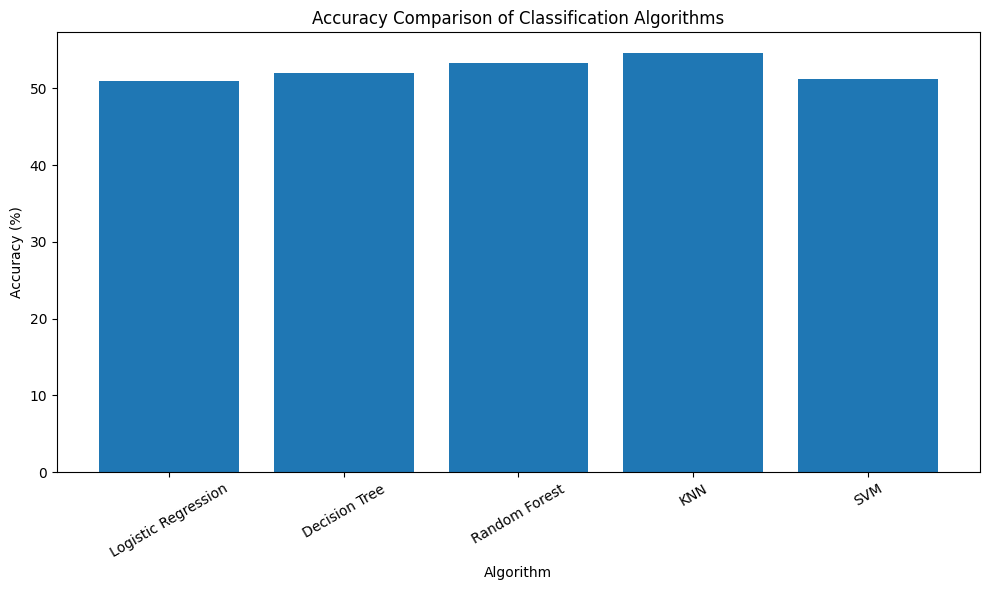

In [15]:
plt.figure(figsize=(10,6))
plt.bar(results["Algorithm"], results["Accuracy"] * 100)
plt.title("Accuracy Comparison of Classification Algorithms")
plt.xlabel("Algorithm")
plt.ylabel("Accuracy (%)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


## 11. CONFUSION MATRIX COMPARISON

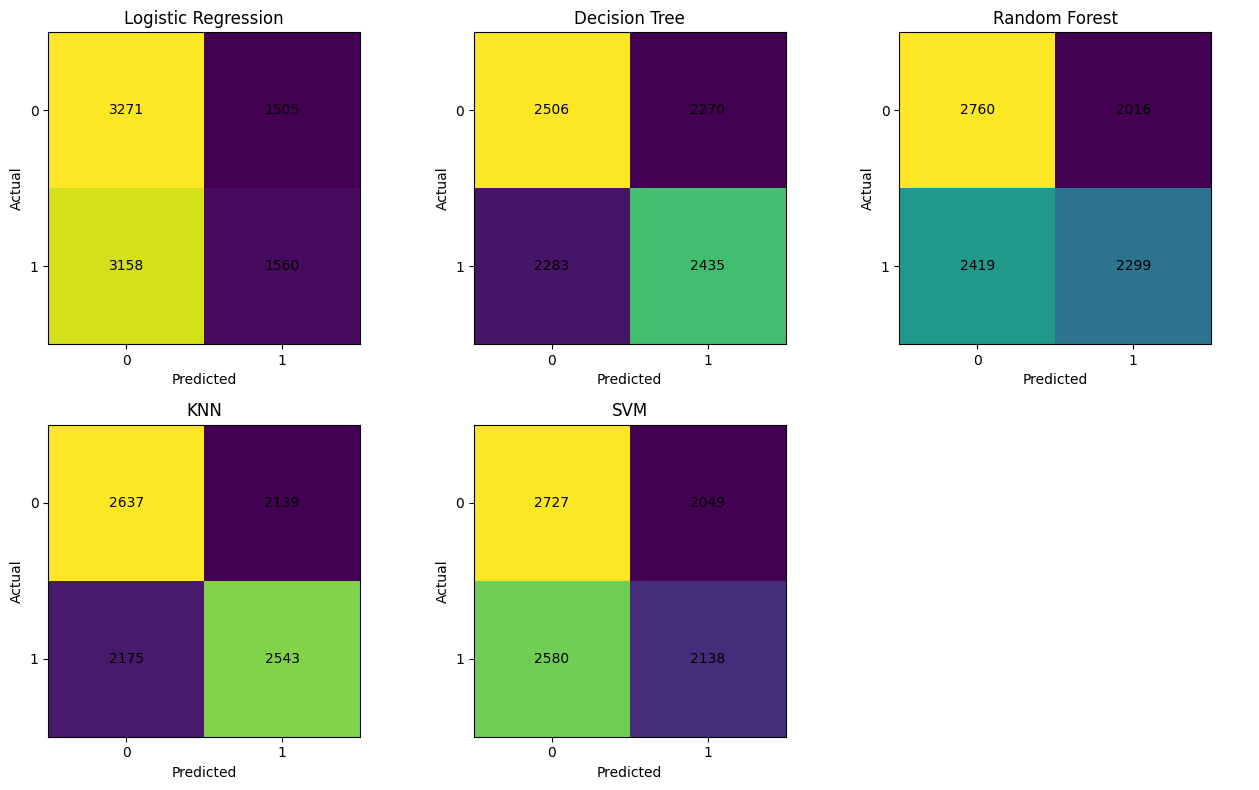

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(13, 8))
axes = axes.flatten()

for i, (name, pred) in enumerate(predictions.items()):
    cm = confusion_matrix(y_test, pred)
    axes[i].imshow(cm)
    axes[i].set_title(name)
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("Actual")
    axes[i].set_xticks([0, 1])
    axes[i].set_yticks([0, 1])
    for r in range(2):
        for c in range(2):
            axes[i].text(c, r, cm[r, c], ha="center", va="center")

axes[-1].axis("off")
plt.tight_layout()
plt.show()


## 12. FINAL MODEL TRAINING

In [17]:
best_index = results["F1 Score"].idxmax()
best_algorithm = results.loc[best_index, "Algorithm"]

print("Best Model:", best_algorithm)
print("Best Accuracy:", round(results.loc[best_index, "Accuracy"]*100, 2), "%")
print("Best F1 Score:", round(results.loc[best_index, "F1 Score"]*100, 2), "%")

# Retrain the selected algorithm on all usable records.
if best_algorithm == "Logistic Regression":
    final_scaler = StandardScaler()
    final_model = LogisticRegression(random_state=42, max_iter=5000)
    final_model.fit(final_scaler.fit_transform(X), y)

elif best_algorithm == "Decision Tree":
    final_scaler = None
    final_model = DecisionTreeClassifier(random_state=42)
    final_model.fit(X, y)

elif best_algorithm == "Random Forest":
    final_scaler = None
    final_model = RandomForestClassifier(n_estimators=100, random_state=42)
    final_model.fit(X, y)

elif best_algorithm == "KNN":
    final_scaler = StandardScaler()
    final_model = KNeighborsClassifier(n_neighbors=5)
    final_model.fit(final_scaler.fit_transform(X), y)

else:
    final_scaler = StandardScaler()
    final_model = SVC(kernel="rbf", random_state=42)
    final_model.fit(final_scaler.fit_transform(X), y)

print("Final model training completed!")


Best Model: KNN
Best Accuracy: 54.56 %
Best F1 Score: 54.11 %
Final model training completed!


## 13. FINAL MODEL EVALUATION

In [ ]:
```python
# ============================================================
# 13. FINAL MODEL EVALUATION - ALL 5 MODELS
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# ------------------------------------------------------------
# TEST ALL FIVE MODELS ON THE SAME 20% TEST DATA
# ------------------------------------------------------------

final_results = []
final_predictions = {}

print("=" * 80)
print("FINAL MODEL EVALUATION - ALL 5 MODELS")
print("=" * 80)

print(f"\nTest data shape: {X_test.shape}")
print(f"Number of test records: {len(X_test)}")


# ------------------------------------------------------------
# EVALUATE EACH MODEL
# ------------------------------------------------------------

for model_name, model in tuned_models.items():

    print("\n" + "=" * 80)
    print(f"MODEL: {model_name}")
    print("=" * 80)

    # Predict on the SAME 20% test data
    y_pred = model.predict(X_test)

    # Save predictions
    final_predictions[model_name] = y_pred

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    # Store results
    final_results.append({
        "Model": model_name,
        "Accuracy": accuracy * 100,
        "Precision": precision * 100,
        "Recall": recall * 100,
        "F1 Score": f1 * 100
    })

    # Display metrics
    print(f"\nAccuracy  : {accuracy * 100:.2f}%")
    print(f"Precision : {precision * 100:.2f}%")
    print(f"Recall    : {recall * 100:.2f}%")
    print(f"F1 Score  : {f1 * 100:.2f}%")

    # Classification report
    print("\nClassification Report:")
    print(
        classification_report(
            y_test,
            y_pred,
            target_names=["No", "Yes"],
            zero_division=0
        )
    )

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["No", "Yes"],
        yticklabels=["No", "Yes"]
    )

    plt.title(f"{model_name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# FINAL COMPARISON TABLE
# ------------------------------------------------------------

final_results_df = pd.DataFrame(final_results)

# Sort according to test accuracy
final_results_df = final_results_df.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)


print("\n" + "=" * 80)
print("FINAL TEST DATA COMPARISON")
print("=" * 80)

display(
    final_results_df.style.format({
        "Accuracy": "{:.2f}%",
        "Precision": "{:.2f}%",
        "Recall": "{:.2f}%",
        "F1 Score": "{:.2f}%"
    })
)


# ------------------------------------------------------------
# ACCURACY COMPARISON GRAPH
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.bar(
    final_results_df["Model"],
    final_results_df["Accuracy"]
)

plt.title("Accuracy Comparison of All 5 Models on Test Data")
plt.xlabel("Machine Learning Model")
plt.ylabel("Test Accuracy (%)")
plt.xticks(rotation=20)
plt.ylim(0, 100)

for i, value in enumerate(final_results_df["Accuracy"]):
    plt.text(
        i,
        value + 1,
        f"{value:.2f}%",
        ha="center",
        fontweight="bold"
    )

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# SELECT BEST MODEL
# ------------------------------------------------------------

best_model_name = final_results_df.loc[0, "Model"]
best_accuracy = final_results_df.loc[0, "Accuracy"]

best_model = tuned_models[best_model_name]
best_predictions = final_predictions[best_model_name]


print("\n" + "=" * 80)
print("BEST MODEL")
print("=" * 80)

print(f"Best Model      : {best_model_name}")
print(f"Test Accuracy   : {best_accuracy:.2f}%")

print("\nThe best model is selected based on its performance")
print("on the same untouched 20% test data.")


# ------------------------------------------------------------
# FINAL BEST MODEL EVALUATION
# ------------------------------------------------------------

print("\n" + "=" * 80)
print(f"FINAL EVALUATION OF BEST MODEL: {best_model_name}")
print("=" * 80)

best_precision = precision_score(
    y_test,
    best_predictions,
    average="weighted",
    zero_division=0
)

best_recall = recall_score(
    y_test,
    best_predictions,
    average="weighted",
    zero_division=0
)

best_f1 = f1_score(
    y_test,
    best_predictions,
    average="weighted",
    zero_division=0
)

print(f"\nAccuracy  : {best_accuracy:.2f}%")
print(f"Precision : {best_precision * 100:.2f}%")
print(f"Recall    : {best_recall * 100:.2f}%")
print(f"F1 Score  : {best_f1 * 100:.2f}%")


print("\nFinal Classification Report:")
print(
    classification_report(
        y_test,
        best_predictions,
        target_names=["No", "Yes"],
        zero_division=0
    )
)


# ------------------------------------------------------------
# FINAL CONFUSION MATRIX FOR BEST MODEL
# ------------------------------------------------------------

best_cm = confusion_matrix(
    y_test,
    best_predictions
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    best_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No", "Yes"],
    yticklabels=["No", "Yes"]
)

plt.title(f"Final Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# FINAL SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("FINAL SUMMARY")
print("=" * 80)

print(f"Models Evaluated : {len(tuned_models)}")
print(f"Test Records     : {len(X_test)}")
print(f"Best Model       : {best_model_name}")
print(f"Best Accuracy    : {best_accuracy:.2f}%")

print("\nAll five models were tested using the same 20% test dataset.")
print("The model with the highest test accuracy is selected as the best model.")
```


ModuleNotFoundError: No module named 'seaborn'

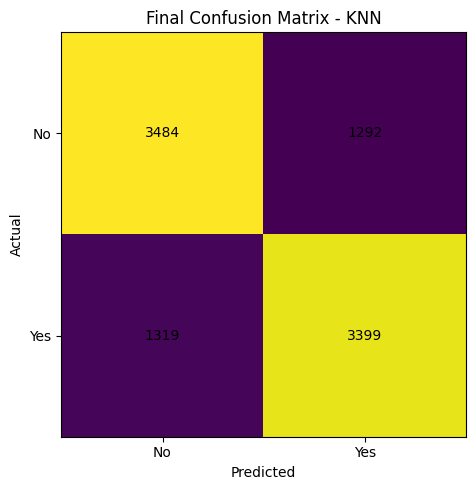

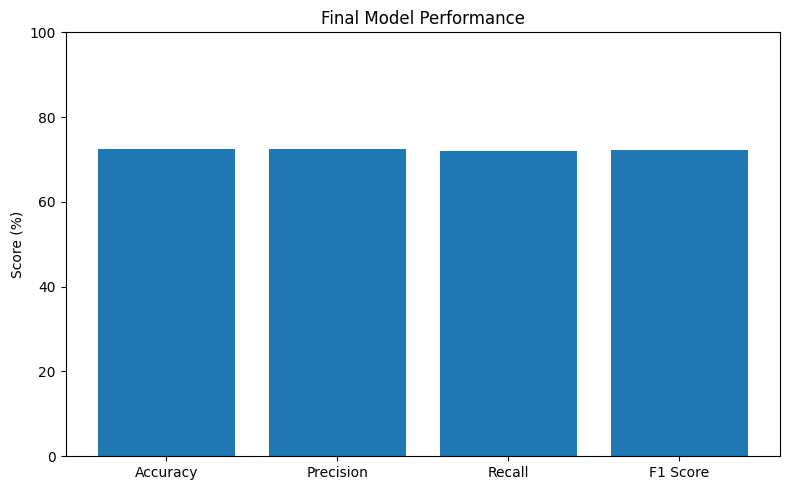

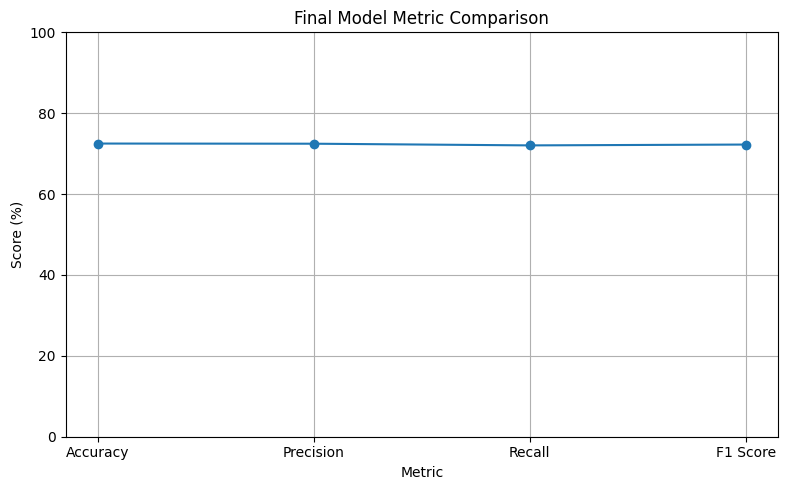

In [19]:
# Final confusion matrix
plt.figure(figsize=(6,5))
plt.imshow(final_cm)
plt.title(f"Final Confusion Matrix - {best_algorithm}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks([0,1], target_encoder.classes_)
plt.yticks([0,1], target_encoder.classes_)

for r in range(2):
    for c in range(2):
        plt.text(c, r, final_cm[r,c], ha="center", va="center")

plt.tight_layout()
plt.show()

# Final bar graph
final_metrics = pd.Series({
    "Accuracy": final_accuracy,
    "Precision": final_precision,
    "Recall": final_recall,
    "F1 Score": final_f1
})

plt.figure(figsize=(8,5))
plt.bar(final_metrics.index, final_metrics.values*100)
plt.title("Final Model Performance")
plt.ylabel("Score (%)")
plt.ylim(0,100)
plt.tight_layout()
plt.show()

# Final line chart
plt.figure(figsize=(8,5))
plt.plot(final_metrics.index, final_metrics.values*100, marker="o")
plt.title("Final Model Metric Comparison")
plt.xlabel("Metric")
plt.ylabel("Score (%)")
plt.ylim(0,100)
plt.grid(True)
plt.tight_layout()
plt.show()


## 14. PREDICTION SYSTEM — FEATURE EXTRACTOR

In [20]:
def create_student_features(
    study_hours, attendance, previous_grades, extracurricular,
    parent_education, assignment_completion, mock_test_score,
    self_study_hours
):
    new_student = pd.DataFrame({
        "Study Hours per Week": [study_hours],
        "Attendance Rate": [attendance],
        "Previous Grades": [previous_grades],
        "Participation in Extracurricular Activities": [extracurricular],
        "Parent Education Level": [parent_education],
        "Assignment Completion Rate": [assignment_completion],
        "Mock Test Score": [mock_test_score],
        "Daily Self-Study Hours": [self_study_hours]
    })

    for col in categorical_columns:
        encoder = feature_encoders[col]
        value = str(new_student.loc[0, col])
        if value not in encoder.classes_:
            raise ValueError(
                f"Unknown {col}: {value}. Allowed values: {list(encoder.classes_)}"
            )
        new_student[col] = encoder.transform([value])

    return new_student[X.columns]


### 15. TEST FEATURE EXTRACTOR / CREATE DATA FEATURE

In [21]:
new_student_features = create_student_features(
    study_hours=20,
    attendance=88,
    previous_grades=80,
    extracurricular="Yes",
    parent_education="Bachelor",
    assignment_completion=90,
    mock_test_score=85,
    self_study_hours=3
)

print("New student's extracted features:")
display(new_student_features)


New student's extracted features:


,Study Hours per Week,Attendance Rate,Previous Grades,Participation in Extracurricular Activities,Parent Education Level,Assignment Completion Rate,Mock Test Score,Daily Self-Study Hours
0,20,88,80,1,1,90,85,3


### 16. TEST FINAL MODEL

In [22]:
if final_scaler is not None:
    prediction_input = final_scaler.transform(new_student_features)
else:
    prediction_input = new_student_features

prediction = final_model.predict(prediction_input)[0]
predicted_result = target_encoder.inverse_transform([prediction])[0]

print("Predicted Result:", predicted_result)

if predicted_result == "Yes":
    print("Prediction: PASS")
else:
    print("Prediction: FAIL")


Predicted Result: No
Prediction: FAIL


## 17. TEST MODEL WITH MULTIPLE STUDENTS

In [23]:
test_students = [
    {
        "study_hours": 25, "attendance": 92, "previous_grades": 88,
        "extracurricular": "Yes", "parent_education": "Bachelor",
        "assignment_completion": 95, "mock_test_score": 90, "self_study_hours": 4
    },
    {
        "study_hours": 8, "attendance": 55, "previous_grades": 45,
        "extracurricular": "No", "parent_education": "High School",
        "assignment_completion": 50, "mock_test_score": 42, "self_study_hours": 1
    }
]

for i, student in enumerate(test_students, start=1):
    features = create_student_features(**student)
    if final_scaler is not None:
        features_for_model = final_scaler.transform(features)
    else:
        features_for_model = features
    pred = final_model.predict(features_for_model)[0]
    result = target_encoder.inverse_transform([pred])[0]
    print(f"Student {i}: {result}")


Student 1: No
Student 2: Yes
